In [12]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
spot_initial = 100.0 #current asset price $100
mu = 0.08            #assumed annual drift 8%  
sigma = 0.20         #annual volatility 20%
years = 1.0          #simulation duration 1 year
steps = 252          #trading days during simulation 252 days

dt = years/steps     #increment size 1/252 year

print(f"Time step size:{dt:.6f} years")#shows increment to 6 decimals
print(f"Number of simulated intervals: {steps}")#shows total trading days

Time-step size:0.003968 years
Number of simulated intervals: 252


[ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519 -1.30217951
  0.1278404  -0.31624259 -0.01680116 -0.85304393]
Number of shocks:  252
Sample Mean:  -0.04837018292335877
Sample standard deviation:  0.9357625168041708


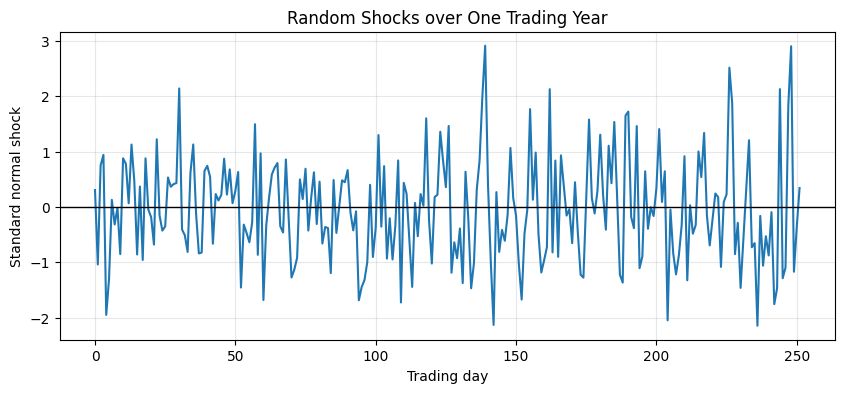

[ 0.01919537 -0.06551284  0.04727398  0.05925001 -0.12290366 -0.0820296
  0.00805319 -0.01992141 -0.00105837 -0.05373672]
Sample Mean:  -0.0030470351163312042
Sample standard deviation:  0.05894749775427943
Expected standard deviation:  0.06299407883487121
Daily drift component:  0.00023809523809523807
Random component:  [ 0.00383907 -0.01310257  0.0094548   0.01185    -0.02458073]
Log returns:  [ 0.00407717 -0.01286447  0.00969289  0.0120881  -0.02434264]
253
Initial price:  100.0
Final simulated price:  91.06737490367284
Number of prices:  253


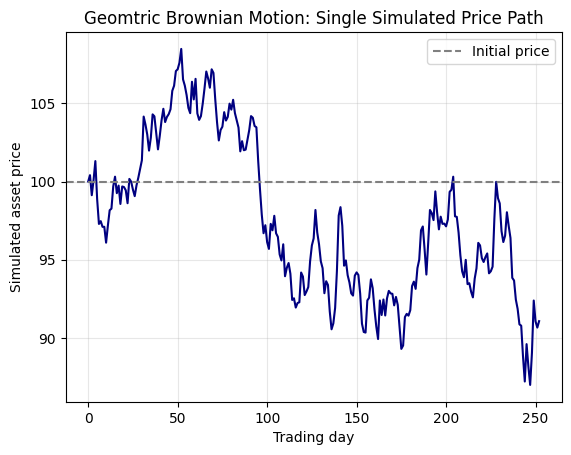

In [23]:
rng = np.random.default_rng(42) #random number generator PCG64 with seed

z = rng.standard_normal(steps) #standard normal shock each trading day  

print(z[:10]) #shows first 10 array values
print("Number of shocks: ", len(z)) #number of random shocks in array   
print("Sample Mean: ", z.mean()) #mean should be near 0     
print("Sample standard deviation: ", z.std()) #standard deviation near 1

plt.figure(figsize=(10,4))
plt.plot(z)
plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Trading day")
plt.ylabel("Standard normal shock")
plt.title("Random Shocks over One Trading Year")
plt.grid(alpha=0.3)

plt.show() #shows random inputs impacting price fluctionations

delta_w = np.sqrt(dt)*z #Brownian/Wiener process increment

print(delta_w[:10]) #shows first 10 array values
print("Sample Mean: ", delta_w.mean()) #mean should be near 0
print("Sample standard deviation: ", delta_w.std()) #near (1/252)^1/2
print("Expected standard deviation: ", np.sqrt(dt)) #is (1/252)^1/2

drift_component = (mu-0.5*sigma**2)*dt #deterministic growth term,
                                       #including Ito correction  

random_component = sigma*delta_w       #stochastic return scaled by
                                       #annual volatility

log_returns = drift_component + random_component

print("Daily drift component: ", drift_component)
print("Random component: ", random_component[:5])
print("Log returns: ", log_returns[:5])

cumulative_log_returns = np.cumsum(log_returns)
cumulative_log_returns = np.concatenate(([0.0], cumulative_log_returns))

print(len(cumulative_log_returns))

price_path = spot_initial*np.exp(cumulative_log_returns)

print("Initial price: ", price_path[0])
print("Final simulated price: ", price_path[-1])
print("Number of prices: ", len(price_path))

days = np.arange(steps + 1)

plt.figsize=(10,5)
plt.plot(days, price_path, color="navy", linewidth=1.5)
plt.axhline(spot_initial,
            color="gray",
            linestyle="--",
            label="Initial price"
            )
plt.xlabel("Trading day")
plt.ylabel("Simulated asset price")
plt.title("Geomtric Brownian Motion: Single Simulated Price Path")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Interpretation


This notebook outlines the stochastic model which will be used for 
Monte Carlo simulation and derivative pricing analysis.

Simulates one possible asset price trajectory using geometric Brownian
motion model to approximate random price volatility, combining 
deterministic drift with stochastic Brownian incrememnts.

Standard normal values are generated to represent independent shocks 
during year of trading day intervals. Shocks are scaled by the square
root of the time step size and assumed annual volatility.

Simulated price is initially $100 and after 252 trading days is ~$91.07.
Assumed annual drift is positive, but a single path represents only one
possible outcome that accounts for annual drift, and the drift terms 
describes an expected trend over many possible paths rather than a 
guaranteed return for each path. 
